# Email Spam Detection using Machine Learning

## Objective

The objective of this project is to classify SMS messages as Spam or Ham using Machine Learning and Natural Language Processing (NLP).

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLTK
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\albij\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\albij\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [8]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [6]:
df = df[['v1', 'v2']]

df.columns = ['Label', 'Message']

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 5)


In [10]:
print(df.dtypes)

v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object


In [11]:
print(df.isnull().sum())

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [14]:
df['Label'].value_counts()

KeyError: 'Label'

In [15]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [16]:
df = df[['v1', 'v2']]
df.columns = ['Label', 'Message']

print(df.columns)

Index(['Label', 'Message'], dtype='str')


In [17]:
df['Label'].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [18]:
df['Message_Length'] = df['Message'].apply(len)

df.head()

,Label,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

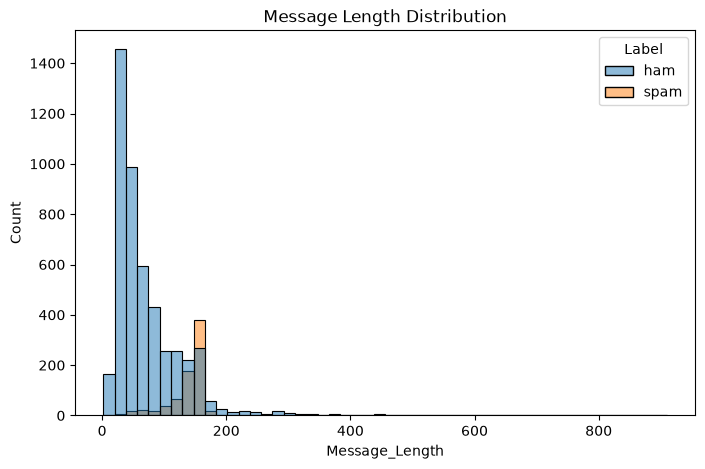

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Message_Length',
    hue='Label',
    bins=50
)

plt.title("Message Length Distribution")

plt.show()

In [22]:
df['Label'] = df['Label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Label,Message,Message_Length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
X = df['Message']
y = df['Label']

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.968609865470852

Confusion Matrix:
[[965   0]
 [ 35 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9443946188340807

Confusion Matrix:
[[962   3]
 [ 59  91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



In [30]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.968610
1,Logistic Regression,0.944395


# Conclusion

This project successfully classified SMS messages as Spam or Ham using Machine Learning and Natural Language Processing (NLP).

The dataset was preprocessed by removing unnecessary columns, converting labels into numerical values, and transforming text messages into numerical features using TF-IDF Vectorization.

Two machine learning models were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression

## Model Performance

| Model | Accuracy |
|--------|---------:|
| Multinomial Naive Bayes | **96.86%** |
| Logistic Regression | **94.44%** |

The Multinomial Naive Bayes classifier achieved the highest accuracy and was selected as the best-performing model for this spam detection task.

This project demonstrates how Natural Language Processing and Machine Learning can effectively detect spam messages with high accuracy.